Columns in dataset:
Index(['city_mpg', 'class', 'combination_mpg', 'cylinders', 'displacement',
       'drive', 'fuel_type', 'highway_mpg', 'make', 'model', 'transmission',
       'year'],
      dtype='object')

Missing values before filling:
cylinders          2
displacement       2
year               0
combination_mpg    0
dtype: int64

Missing values after filling:
cylinders          0
displacement       0
year               0
combination_mpg    0
dtype: int64

Statistical Summary:
        cylinders  displacement         year  combination_mpg
count  550.000000    550.000000   550.000000       550.000000
mean     5.315693      2.931752  2019.000000        24.069091
std      1.756790      1.246143     3.165156         7.478369
min      3.000000      1.200000  2014.000000        14.000000
25%      4.000000      2.000000  2016.000000        20.000000
50%      4.000000      2.500000  2019.000000        23.000000
75%      6.000000      3.500000  2022.000000        27.000000
max     12.000

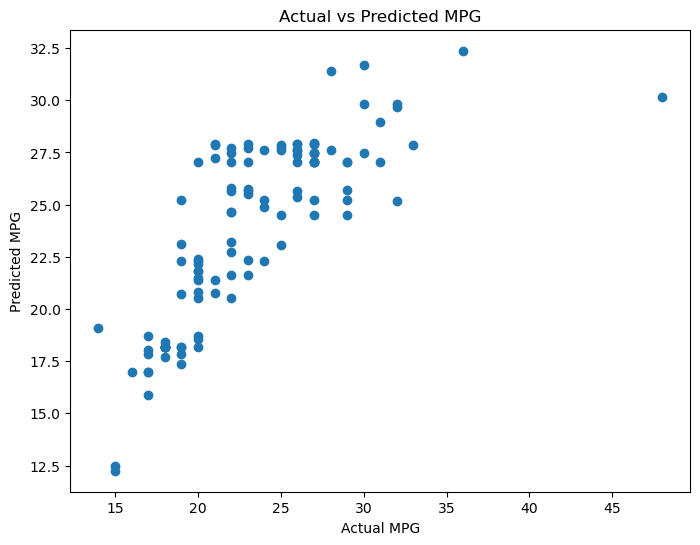

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv(r"D:\Machine Learning (25UAICT4006)\Project (Task)\Explore Car Performance Fuel Efficiency Data\car_data.csv")

# Show columns
print("Columns in dataset:")
print(df.columns)

# Select available columns
df = df[['cylinders', 'displacement', 'year', 'combination_mpg']]

# Check missing values
print("\nMissing values before filling:")
print(df.isnull().sum())

# Fill missing values
df = df.fillna(df.mean(numeric_only=True))

print("\nMissing values after filling:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Features and target
X = df[['cylinders', 'displacement', 'year']]
y = df['combination_mpg']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Polynomial transformation
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Build model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predictions
y_pred = model.predict(X_test_poly)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error:", mse)
print("R2 Score:", r2)

# Predicted vs Actual plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")
plt.show()